## 1. Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("Coffee Shop Sales.xlsx")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [4]:
df.isnull().sum()

,0
transaction_id,0
transaction_date,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype          
---  ------            --------------   -----          
 0   transaction_id    149116 non-null  int64          
 1   transaction_date  149116 non-null  datetime64[ns] 
 2   transaction_time  149116 non-null  timedelta64[ns]
 3   transaction_qty   149116 non-null  int64          
 4   store_id          149116 non-null  int64          
 5   store_location    149116 non-null  object         
 6   product_id        149116 non-null  int64          
 7   unit_price        149116 non-null  float64        
 8   product_category  149116 non-null  object         
 9   product_type      149116 non-null  object         
 10  product_detail    149116 non-null  object         
 11  total_sales       149116 non-null  float64        
 12  datetime          149116 non-null  datetime64[ns] 
dtypes: datetime64[ns](2), float64(2), int64(4), 

In [11]:
df['transaction_time'] = df['transaction_time'].astype(str)
df['transaction_time'] = pd.to_timedelta(df['transaction_time'])

In [13]:
df["total_sales"] = df["unit_price"] * df["transaction_qty"]
df["datetime"] = df['transaction_date'] + df['transaction_time']

In [15]:
df.describe()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,product_id,unit_price,total_sales,datetime
count,149116.000000,149116,149116,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116
mean,74737.371872,2023-04-15 11:50:32.173609984,0 days 12:14:15.815794415,1.438276,5.342063,47.918607,3.382219,4.686367,2023-04-16 00:04:47.989404160
min,1.000000,2023-01-01 00:00:00,0 days 06:00:00,1.000000,3.000000,1.000000,0.800000,0.800000,2023-01-01 07:06:11
25%,37335.750000,2023-03-06 00:00:00,0 days 09:05:10.500000,1.000000,3.000000,33.000000,2.500000,3.000000,2023-03-06 13:37:08
50%,74727.500000,2023-04-24 00:00:00,0 days 11:15:28,1.000000,5.000000,47.000000,3.000000,3.750000,2023-04-24 08:24:32.500000
75%,112094.250000,2023-05-30 00:00:00,0 days 15:25:57,2.000000,8.000000,60.000000,3.750000,6.000000,2023-05-30 07:16:13
max,149456.000000,2023-06-30 00:00:00,0 days 20:59:32,8.000000,8.000000,87.000000,45.000000,360.000000,2023-06-30 20:57:19
std,43153.600016,NaN,0 days 03:45:57.901686173,0.542509,2.074241,17.930020,2.658723,4.227099,NaN


In [17]:
df_location = df.groupby("store_location").agg({
    "total_sales": "sum",
    "transaction_id": "count"
})
df_location

,total_sales,transaction_id
store_location,,
Astoria,232243.91,50599
Hell's Kitchen,236511.17,50735
Lower Manhattan,230057.25,47782


In [24]:
daily_sales_by_location = df.groupby(["transaction_date", "store_location"])["total_sales"].sum().unstack()
daily_sales_by_location

store_location,Astoria,Hell's Kitchen,Lower Manhattan
transaction_date,,,
2023-01-01,868.40,851.45,788.35
2023-01-02,925.50,828.80,649.05
2023-01-03,902.75,906.25,756.00
2023-01-04,808.25,781.65,630.20
2023-01-05,903.05,714.90,800.90
...,...,...,...
2023-06-26,1975.10,1746.10,2154.70
2023-06-27,1861.55,1676.70,2437.40
2023-06-28,1758.10,1445.85,1524.95


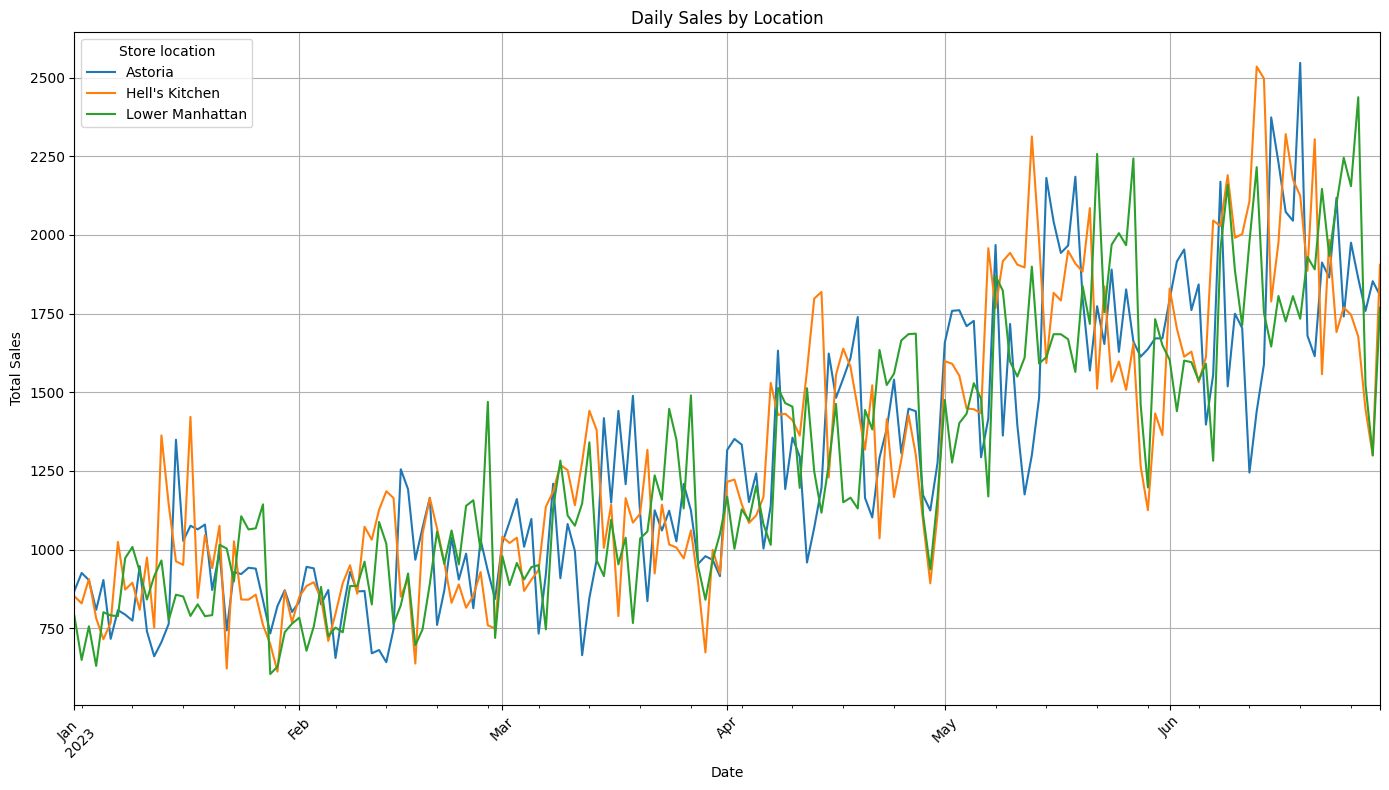

In [28]:
daily_sales_by_location.plot(figsize=(14,8), title = "Daily Sales by Location")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend(title = "Store location")
plt.grid(True)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [32]:
daily_sales_by_location.T

transaction_date,2023-01-01,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,2023-01-10,...,2023-06-21,2023-06-22,2023-06-23,2023-06-24,2023-06-25,2023-06-26,2023-06-27,2023-06-28,2023-06-29,2023-06-30
store_location,,,,,,,,,,,,,,,,,,,,,
Astoria,868.40,925.50,902.75,808.25,903.05,716.05,807.30,793.15,774.01,947.00,...,1614.25,1912.05,1864.40,2117.55,1740.70,1975.1,1861.55,1758.10,1852.75,1807.65
Hell's Kitchen,851.45,828.80,906.25,781.65,714.90,767.20,1024.10,872.83,894.40,808.10,...,2303.83,1557.10,1984.08,1690.80,1769.20,1746.1,1676.70,1445.85,1298.55,1904.93
Lower Manhattan,788.35,649.05,756.00,630.20,800.90,790.60,788.25,972.55,1008.20,930.55,...,1890.30,2145.95,1933.38,2097.75,2244.95,2154.7,2437.40,1524.95,1299.45,1768.74


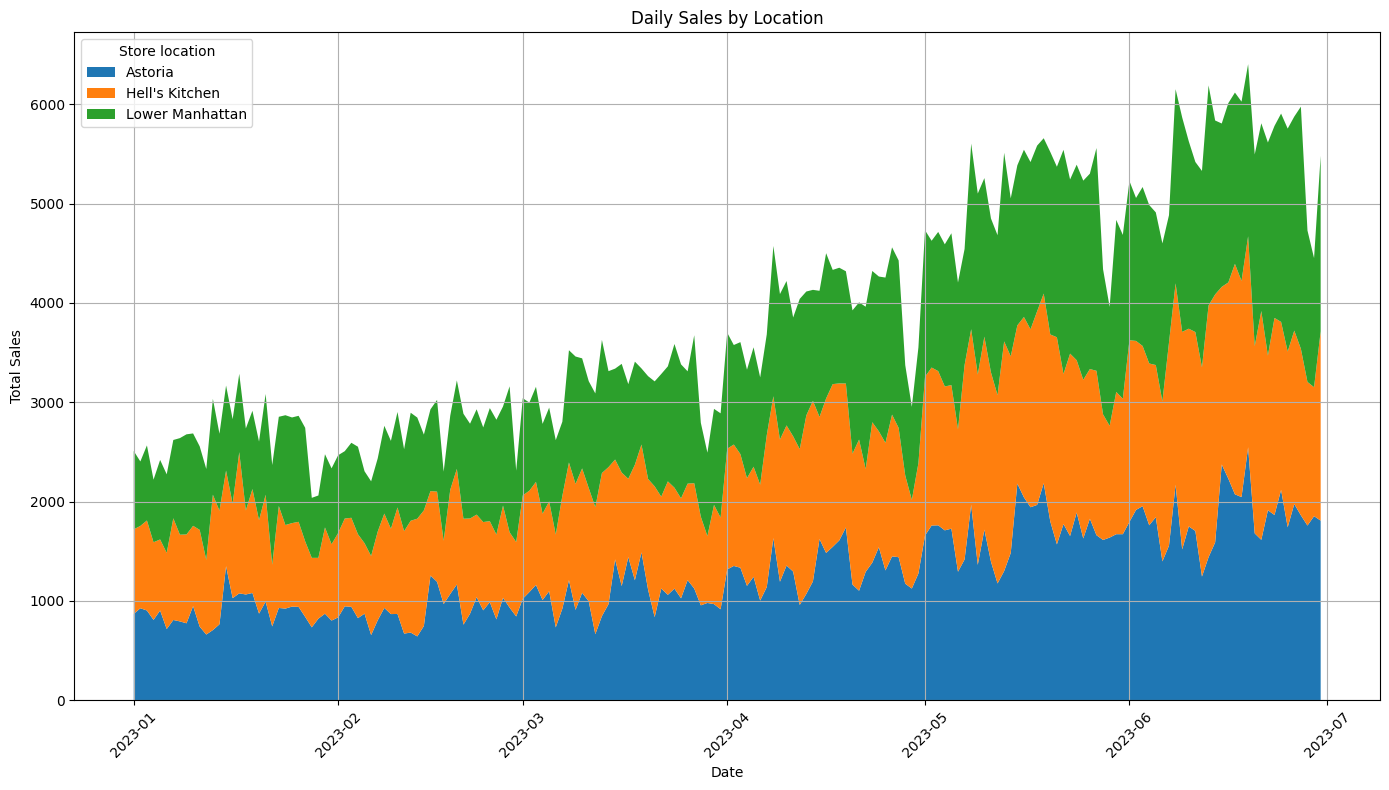

In [31]:
plt.figure(figsize = (14,8))
plt.stackplot(daily_sales_by_location.index, daily_sales_by_location.T, labels = daily_sales_by_location.columns)
plt.title("Daily Sales by Location")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend(title = "Store location", loc = "upper left")
plt.grid(True)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [46]:
daily_sales = df.groupby("transaction_date")["total_sales"].sum().reset_index()

df["day_of_the_week"] = df['datetime'].dt.day_name()
weekly_sales = df.groupby("day_of_the_week")["total_sales"].sum().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]).reset_index()

df["month"] = df["datetime"].dt.to_period("M")
monthly_sales = df.groupby("month")["total_sales"].sum().reset_index()
daily_sales, weekly_sales, monthly_sales

(    transaction_date  total_sales
 0         2023-01-01      2508.20
 1         2023-01-02      2403.35
 2         2023-01-03      2565.00
 3         2023-01-04      2220.10
 4         2023-01-05      2418.85
 ..               ...          ...
 176       2023-06-26      5875.90
 177       2023-06-27      5975.65
 178       2023-06-28      4728.90
 179       2023-06-29      4450.75
 180       2023-06-30      5481.32
 
 [181 rows x 2 columns],
   day_of_the_week  total_sales
 0          Monday    101677.28
 1         Tuesday     99455.94
 2       Wednesday    100313.54
 3        Thursday    100767.78
 4          Friday    101373.00
 5        Saturday     96894.48
 6          Sunday     98330.31,
      month  total_sales
 0  2023-01     81677.74
 1  2023-02     76145.19
 2  2023-03     98834.68
 3  2023-04    118941.08
 4  2023-05    156727.76
 5  2023-06    166485.88)

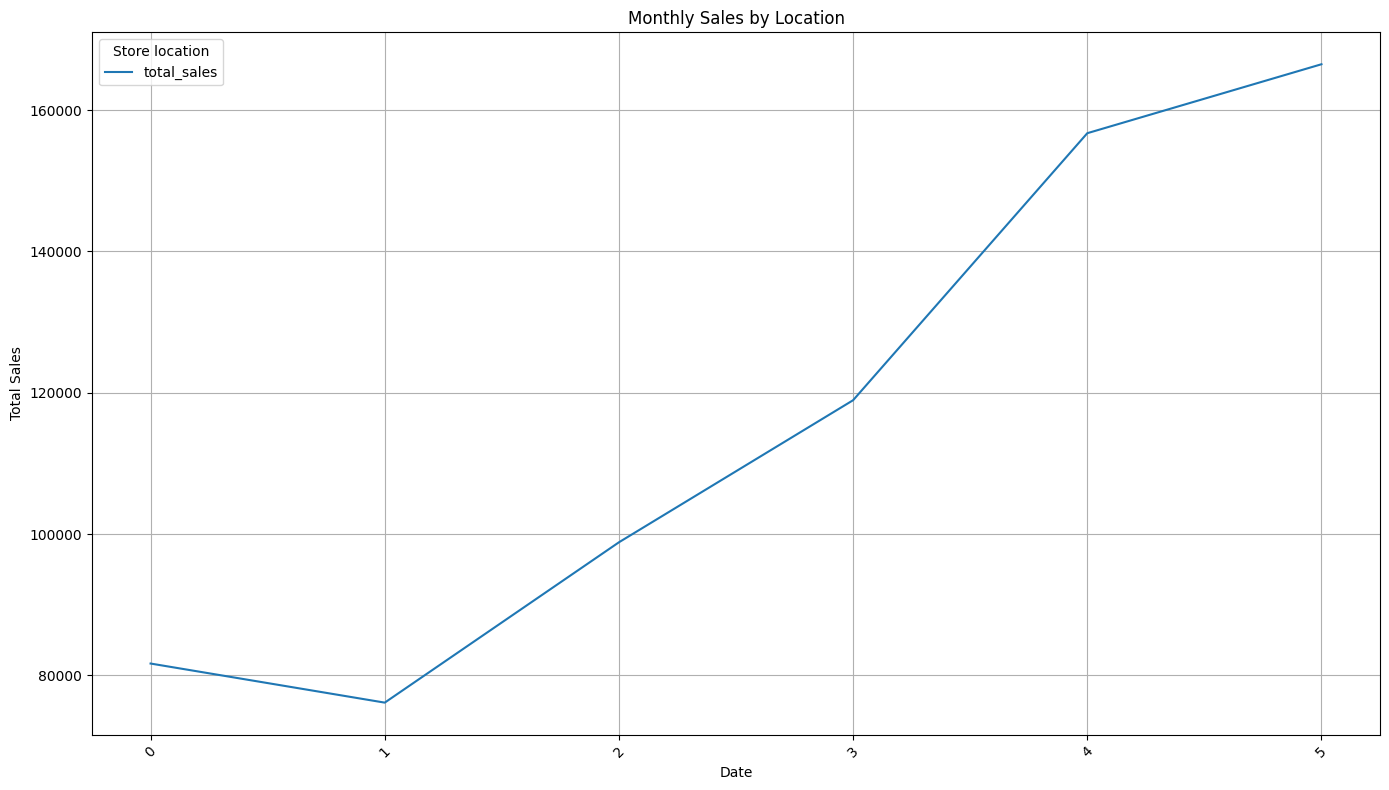

In [47]:
monthly_sales.plot(figsize=(14,8), title = "Monthly Sales by Location")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend(title = "Store location")
plt.grid(True)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [50]:
weekly_sales = df.groupby(["day_of_the_week", "store_location" ])["total_sales"].sum().unstack().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
weekly_sales

store_location,Astoria,Hell's Kitchen,Lower Manhattan
day_of_the_week,,,
Monday,33928.29,33389.51,34359.48
Tuesday,31816.76,34846.47,32792.71
Wednesday,34244.63,33779.09,32289.82
Thursday,34140.37,33468.06,33159.35
Friday,33472.75,34743.18,33157.07
Saturday,31845.93,32599.23,32449.32
Sunday,32795.18,33685.63,31849.50


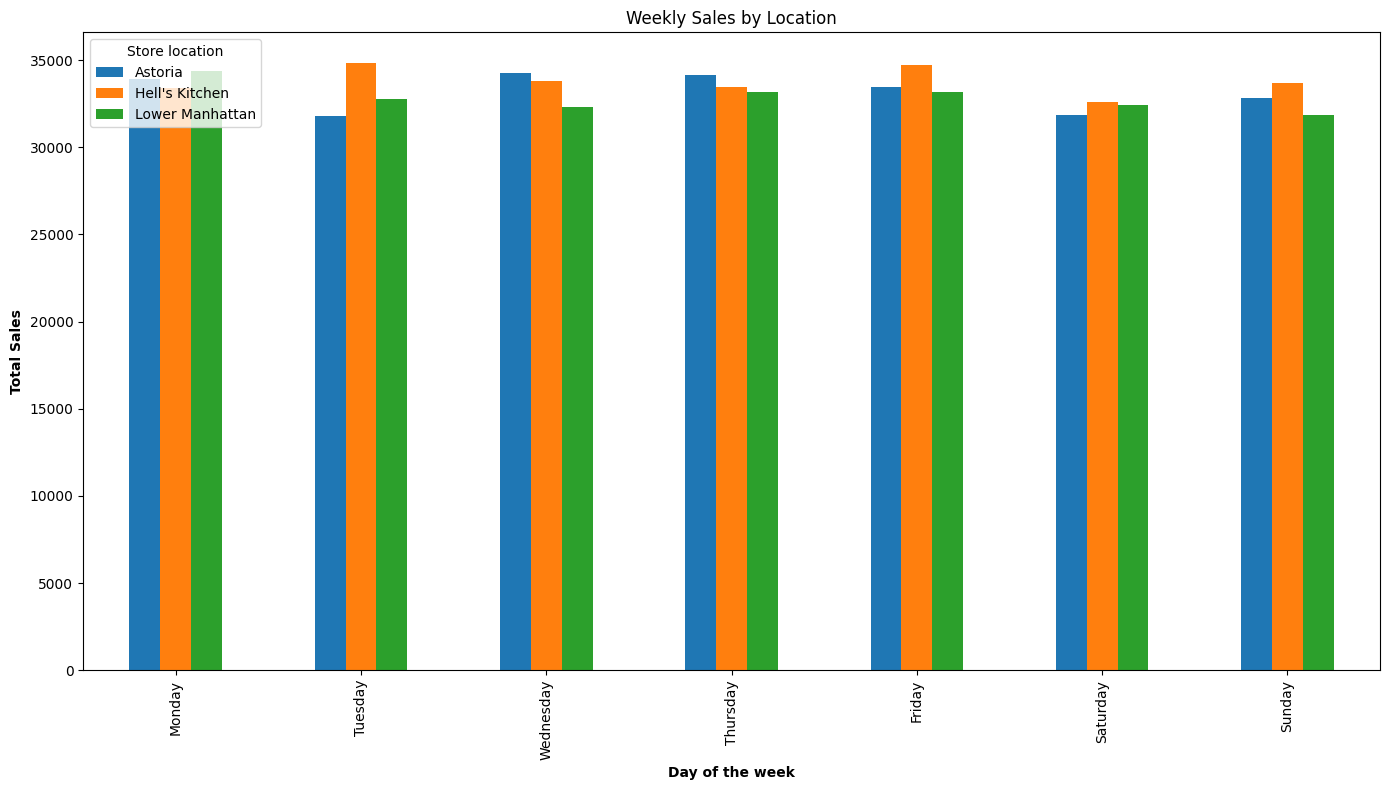

In [52]:
weekly_sales[["Astoria", "Hell's Kitchen", "Lower Manhattan"]].plot(kind = "bar", figsize = (14,8))
plt.xlabel("Day of the week", fontweight = "bold")
plt.ylabel("Total Sales", fontweight = "bold")
plt.title("Weekly Sales by Location")
plt.legend(title = "Store location", loc = "upper left")

plt.tight_layout()
plt.show()

In [56]:
df_category = df.groupby("product_category").agg({
    "total_sales": "sum",
    "transaction_id": "count"
}).sort_values("total_sales", ascending=False)
df_category

,total_sales,transaction_id
product_category,,
Coffee,269952.45,58416
Tea,196405.95,45449
Bakery,82315.64,22796
Drinking Chocolate,72416.00,11468
Coffee beans,40085.25,1753
Branded,13607.00,747
Loose Tea,11213.60,1210
Flavours,8408.80,6790
Packaged Chocolate,4407.64,487
